In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.pylab as pl
from matplotlib.colors import ListedColormap
np.set_printoptions(precision=3)
%matplotlib inline

# Labyrinthe

On considère le problème du labyrinthe abordé dans le premier TD.
On modélise le problème par:
- un ensemble d'états $\mathcal{S}=\left\{ 1,\dots,n \right\}\times
  \left\{ 1,\dots,m \right\}$ qui correspond aux cellules,
- un ensemble d'actions $\mathcal{A}=\left\{ 0,1,2,3 \right\}$ qui correspondent respectivement à "bas", "droite", "haut", "gauche", et dont on utilisera parfois la représentation sous forme de vecteur,
- un ensemble de gains $\mathcal{R}=\left\{ 0,1 \right\}$
- un ensemble d'états appelés "murs intérieurs" $\mathcal{W}\subset \mathcal{A}$.

Les transitions sont toutes déterministes, et sont telles qu'on obtient un gain de 1 lorsqu'on se déplace vers la cellule d'arrivée depuis une cellule voisine, et un gain de 0 sinon. Si l'action choisie correspond à un déplacement non-autorisé (soit qu'il mène à l'extérieur du labyrinthe, soit qu'il mène vers un mur intérieur, soit que l'état actual est un mur intérieur), l'état reste inchangé.

On travaillera avec une valeur $\gamma=.9$ fixée.

La fonction suivante servira à représenter graphiquement le labyrinthe, les politiques, ainsi que les chemins empruntés par les politiques.

In [42]:
def plot(policy=None, path=False):
    grid_size = maze.shape
    fig, ax = plt.subplots(figsize=(grid_size[1]+1, grid_size[0]+1))
    im = ax.imshow(maze, cmap='Greys', interpolation='nearest', extent=[0, grid_size[1], 0, grid_size[0]], alpha=1)
    ax.set_xticks(np.arange(0, grid_size[1]+1, 1), minor=True)
    ax.set_yticks(np.arange(0, grid_size[0]+1, 1), minor=True)
    ax.grid(which="minor", color='black', linestyle='-', linewidth=1)
    ax.set_xticks([])
    ax.set_yticks([])
    if policy is not None:
        # Plot arrows
        for i in range(grid_size[0]):
            for j in range(grid_size[1]):
                action = policy[i, j]
                ax.text(j + 0.5, grid_size[0] - i - 0.5, action_arrows[action],
                        ha='center', va='center', fontsize=12, fontweight='bold')
        if path is True:
            cmap = pl.cm.Reds
            my_cmap = cmap(np.arange(cmap.N))
            my_cmap[:,-1] = np.linspace(0, 1, cmap.N)
            my_cmap = ListedColormap(my_cmap)

            im = ax.imshow(path_array(policy), cmap=my_cmap, interpolation='nearest', extent=[0, grid_size[1], 0, grid_size[0]], alpha=.5)
    plt.show()

Le code suivant construit un labyrinthe aléatoire de taille 30 x 30, avec des murs intérieurs qui ne sont pas tirés de façon indépendante. La case de départ est (0,0) (celle en haut à gauche), et la case d'arrivée est (29,29) (celle en bas à droite). Il est fait en sorte que ces deux cases ne soient pas murées. Les paramètres peuvent bien sûr être modifiés.

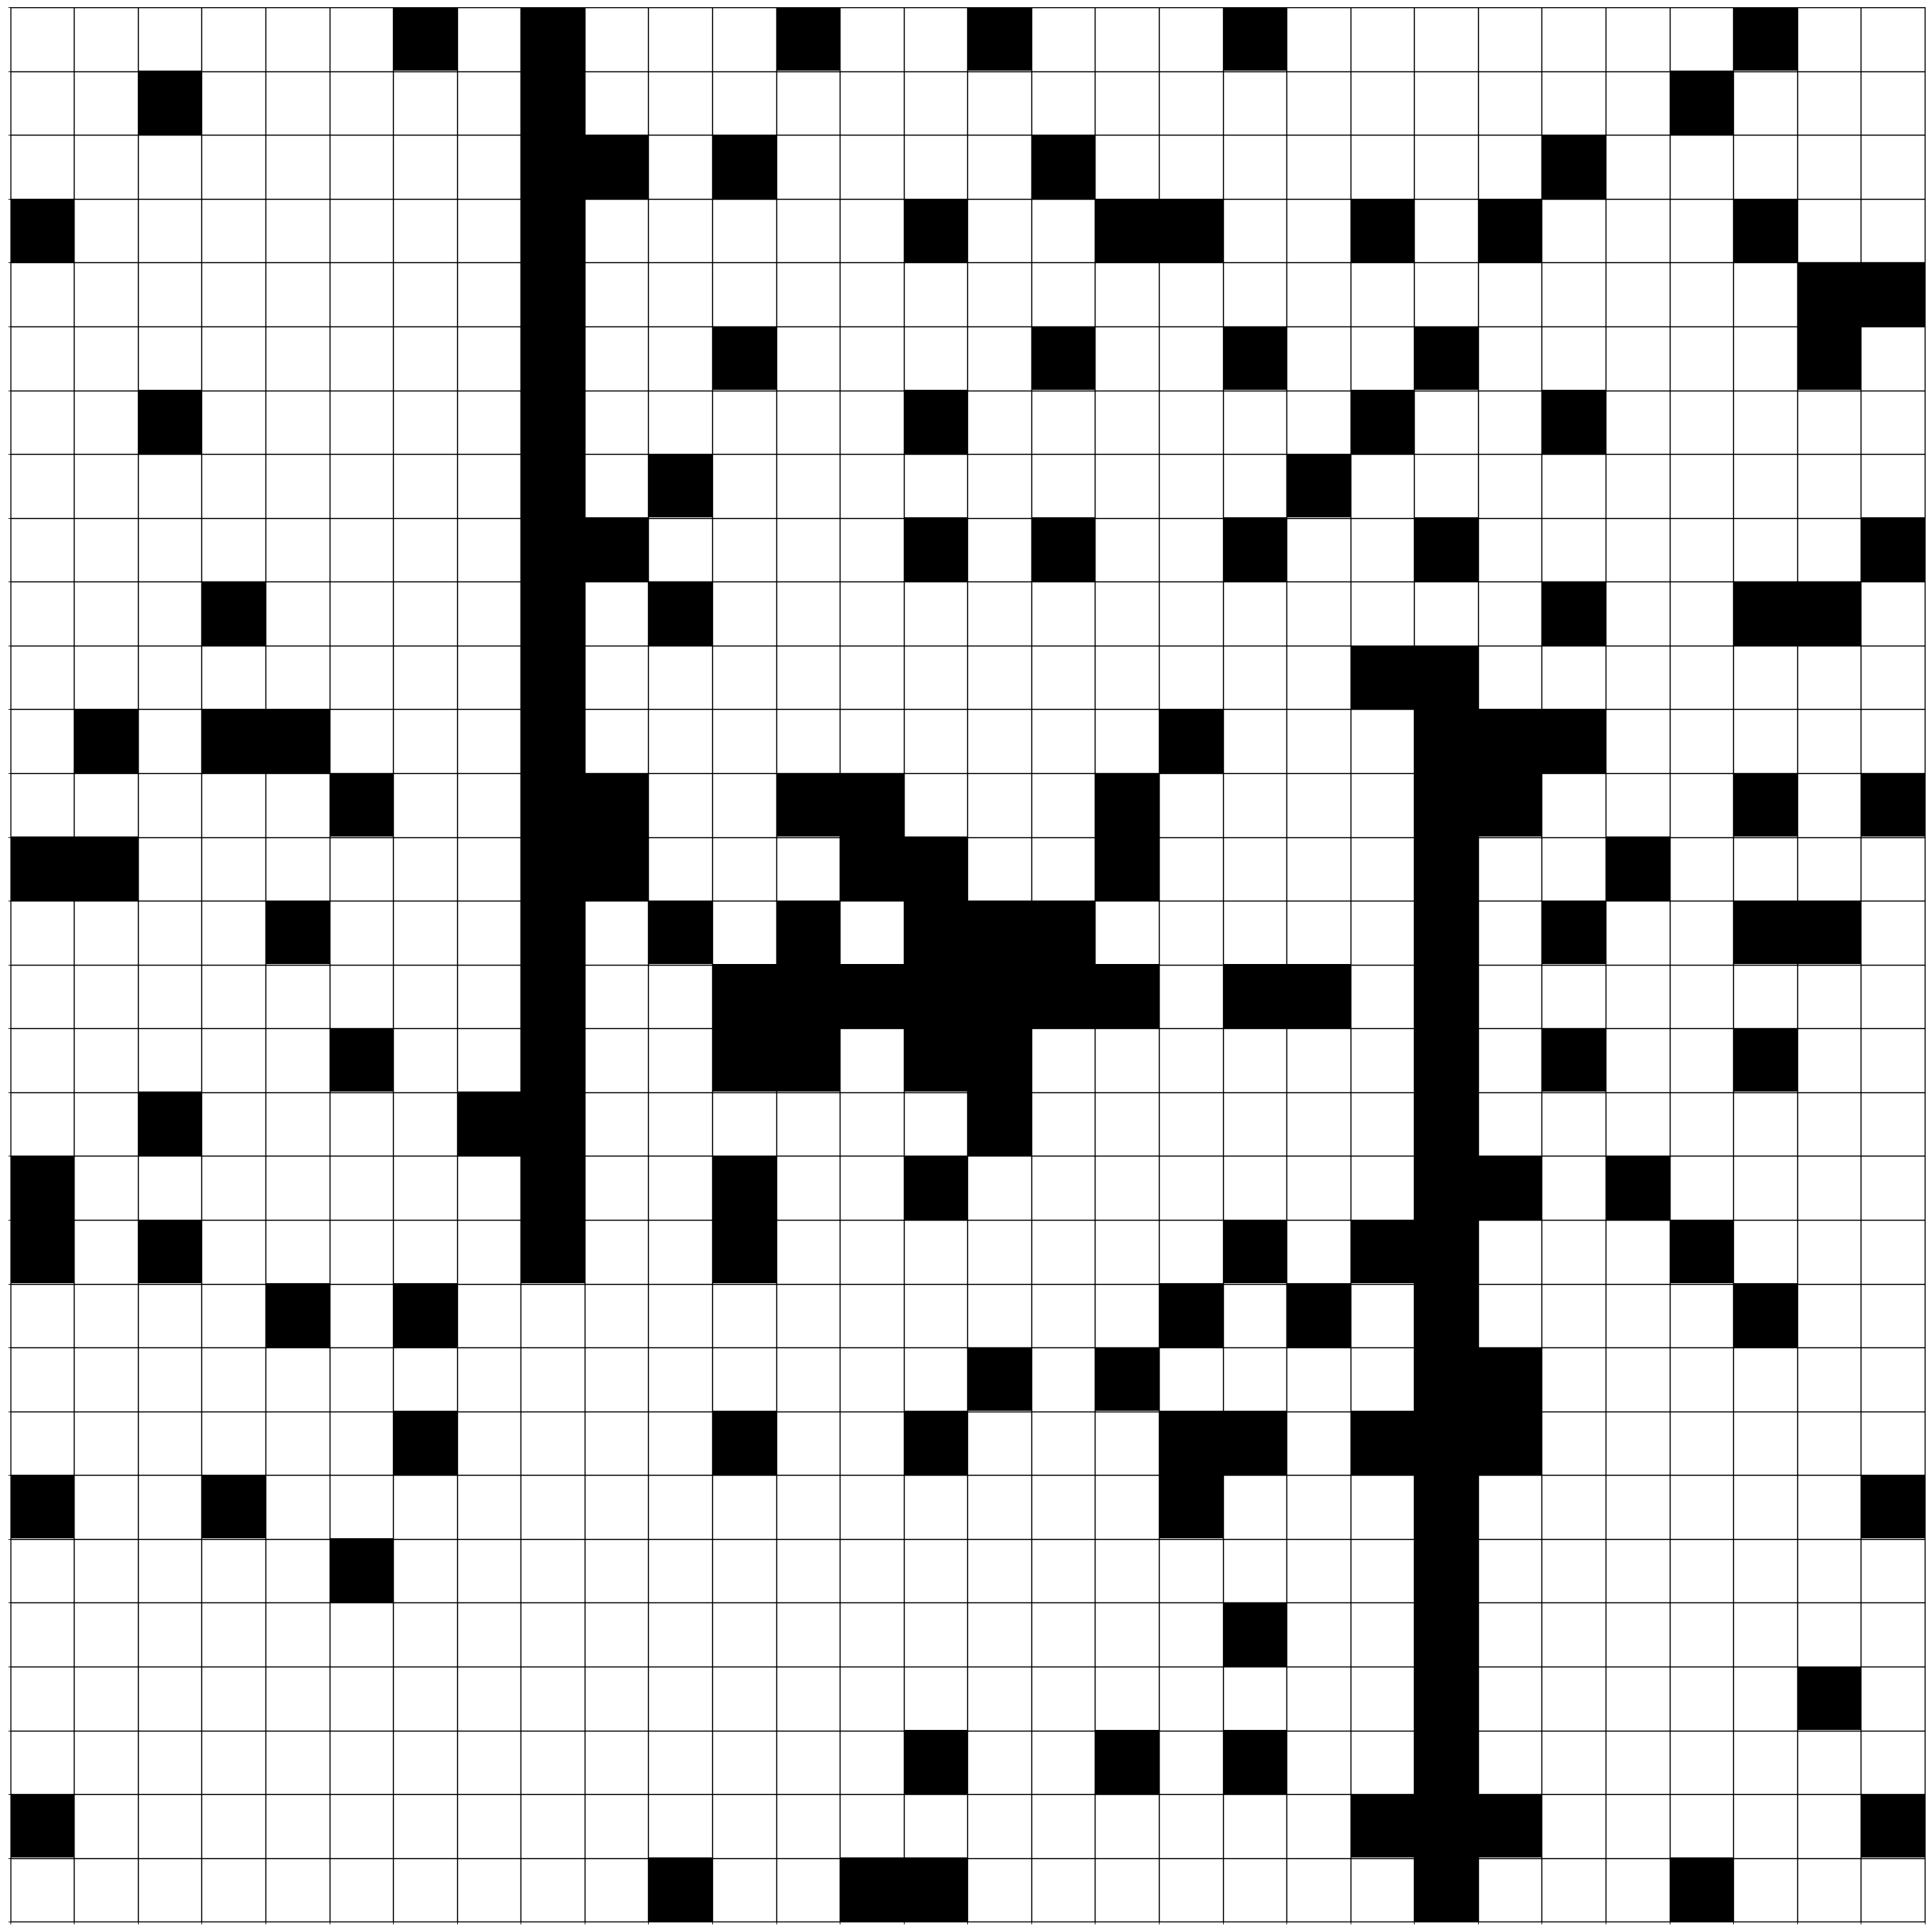

In [43]:
width = 30
height = 30
maze_size = (height, width) # nb lines & nb rows
start_cell = (0,0)
target_cell = (height-1, width-1)

maze = np.random.binomial(1, p=.15, size=maze_size)
maze[:round(2*width/3),round(height/4)] = 1
maze[round(width/3):,round(3*height/4)] = 1
chl = round(2*height/5)
chu = round(3*height/5)
cwl = round(2*width/5)
cwu = round(3*width/5)
maze[chl:chu,cwl:cwu] = np.random.binomial(1, p=.5, size=(chu-chl, cwu-cwl))
maze[start_cell] = 0
maze[target_cell] = 0
plot()

*Attention* : vérifier visuellement que le labyrinthe ainsi obtenu possède un chemin allant de la case de départ à la case d'arriver. Dans le cas contraire, relancer le code ci-dessus afin de générer un autre labyrinthe.

In [44]:
actions = [0,1,2,3]
action_coordinates = {0: np.array([1,0]),# down
                      1: np.array([0,1]), # right
                      2: np.array([-1,0]), # up
                      3: np.array([0,-1])} # left
action_arrows = ['↓', '→', '↑', '←']
gamma = .9

On ne va travailler qu'avec des politiques stationnaires déterministes $\pi:\mathcal{S}\to \mathcal{A}$. On va les représenter par des arrays de taille $n\times m$ à valeurs dans $\left\{ 0,1,2,3 \right\}$.

*Question 1*: Compléter la fonction suivante qui prend en entrée un état (un couple de la forme (i,j)) et une action (un entier parmi 0,1,2,3), et qui renvoie r, s_, qui sont respectivement le gain et le nouvel état. On pourra utiliser la fonction `tuple` qui convertit en n-uplet un objet d'un autre type.

In [45]:
def transition(s,a):
    # Compléter
    new_cell=s+action_coordinates[a]
    r=0.0
    if (new_cell[0]<0) or (new_cell[0]>=maze.shape[0]) or (new_cell[1]<0) or (new_cell[1]>=maze.shape[1]): # check is action is within bounds
        new_cell=s
        
    # check is new cell is not a wall
    elif maze[new_cell[0],new_cell[1]]==1:
        new_cell=s
        
    s_ = (new_cell[0], new_cell[1])
    if s_ == target_cell:
        r=1.0
    return r, s_



*Question 2*: Compléter les fonctions suivantes qui calculent l'image d'une fonction état-valeur par les opérateurs de Bellman $B_{\pi}^{(V)}$ et $B_*^{(V)}$. Une fonction état-valeur sera représentée par un array de taille $n\times m$, et une politique (qu'on suppose donc stationnaire et déterministe), par un array de taille $n\times m$ à valeurs dans $\left\{ 0,1,2,3 \right\}$.

In [46]:
def B_pi(v, pi): 
    # Compléter
    v_= np.zeros_like(v)
    
    # on parcourt  tous les états
    for i in range(maze.shape[0]):
        for j in range(maze.shape[1]):
            # tout est déterministe donc on regarde le nouvel état selon la politique et on regarde son gain
            state=(i,j)
            action=pi[state]
            r,next_s=transition(state,action)
            
            v_[i,j]=v[next_s]*gamma+r

    return v_

def B_star(v): 
    # Compléter
    v_=np.zeros_like(v)
    for i in range(maze.shape[0]):
        for j in range(maze.shape[1]):
            state=(i,j)

            # on cherche la meilleure action que l'on peut faire en étant en state
            value=[]  

            for a in actions:
                r, next_state = transition(state, a)
                action_value = r + gamma * v[next_state]
                value.append(action_value)

            v_[i, j] = np.max(value)
    return v_

*Question 3*: Compléter la fonction suivante qui renvoie une politique gloutonne par rapport à une fonction état-valeur donnée en entrée. On pourra utiliser la fonction np.argmax.

In [47]:
def greedy_policy(v): 

    # Compléter
    #policy pour chaque état
    pi=np.zeros(maze.shape,dtype=int)
    for i in range(maze.shape[0]):
        for j in range(maze.shape[1]):
            state=(i,j)

            # on cherche la meilleure action en l'état state, en testant toute les actions possibles
            value={}
            for a in actions:
                r, next_state = transition(state, a)
                action_value = r + gamma * v[next_state]
                value[a]=action_value
            pi[state]= max(value, key=value.get)
    return pi

*Question 4*: Compléter la fonction suivante qui renvoie le chemin suivi par la politique donnée en argument depuis la cellule de départ. On considère qu'un chemin se termine lorsque qu'une transition donne une cellule déjà visitée par le chemin. Le chemin sera donné sous la forme d'un array de taille $n\times m$ à valeurs dans {0,1}, où 1 correspond aux cellules visitées par le chemin.

In [48]:
def path_array(policy):
    arr = np.zeros_like(maze, dtype=float)

    state = start_cell
    visited = set()
    
    while True:
        i, j = state
        arr[i, j] = 1      # marquer la case dans le chemin
        if state == target_cell:
            break
        
        # éviter les boucles
        if state in visited:
            break
        visited.add(state)

        action = policy[i, j]
        r, next_s = transition(state, action)
        state = next_s

    return arr

Le code suivant donne une fonction état-valeur aléatoire, qui servira de point de départ pour une itération valeur.

In [49]:
v = np.random.random(maze.shape)

*Question 5*: Calculer 50 itérations d'une itération valeur. Observer alors le chemin donné par la politique gloutonne grâce à la fonction plot appelée avec l'option path=True. Un chemin de longeur minimale a-t-il été trouvé ? Si besoin, calculer 50 itérations supplémentaires en relançant la cellule de code.

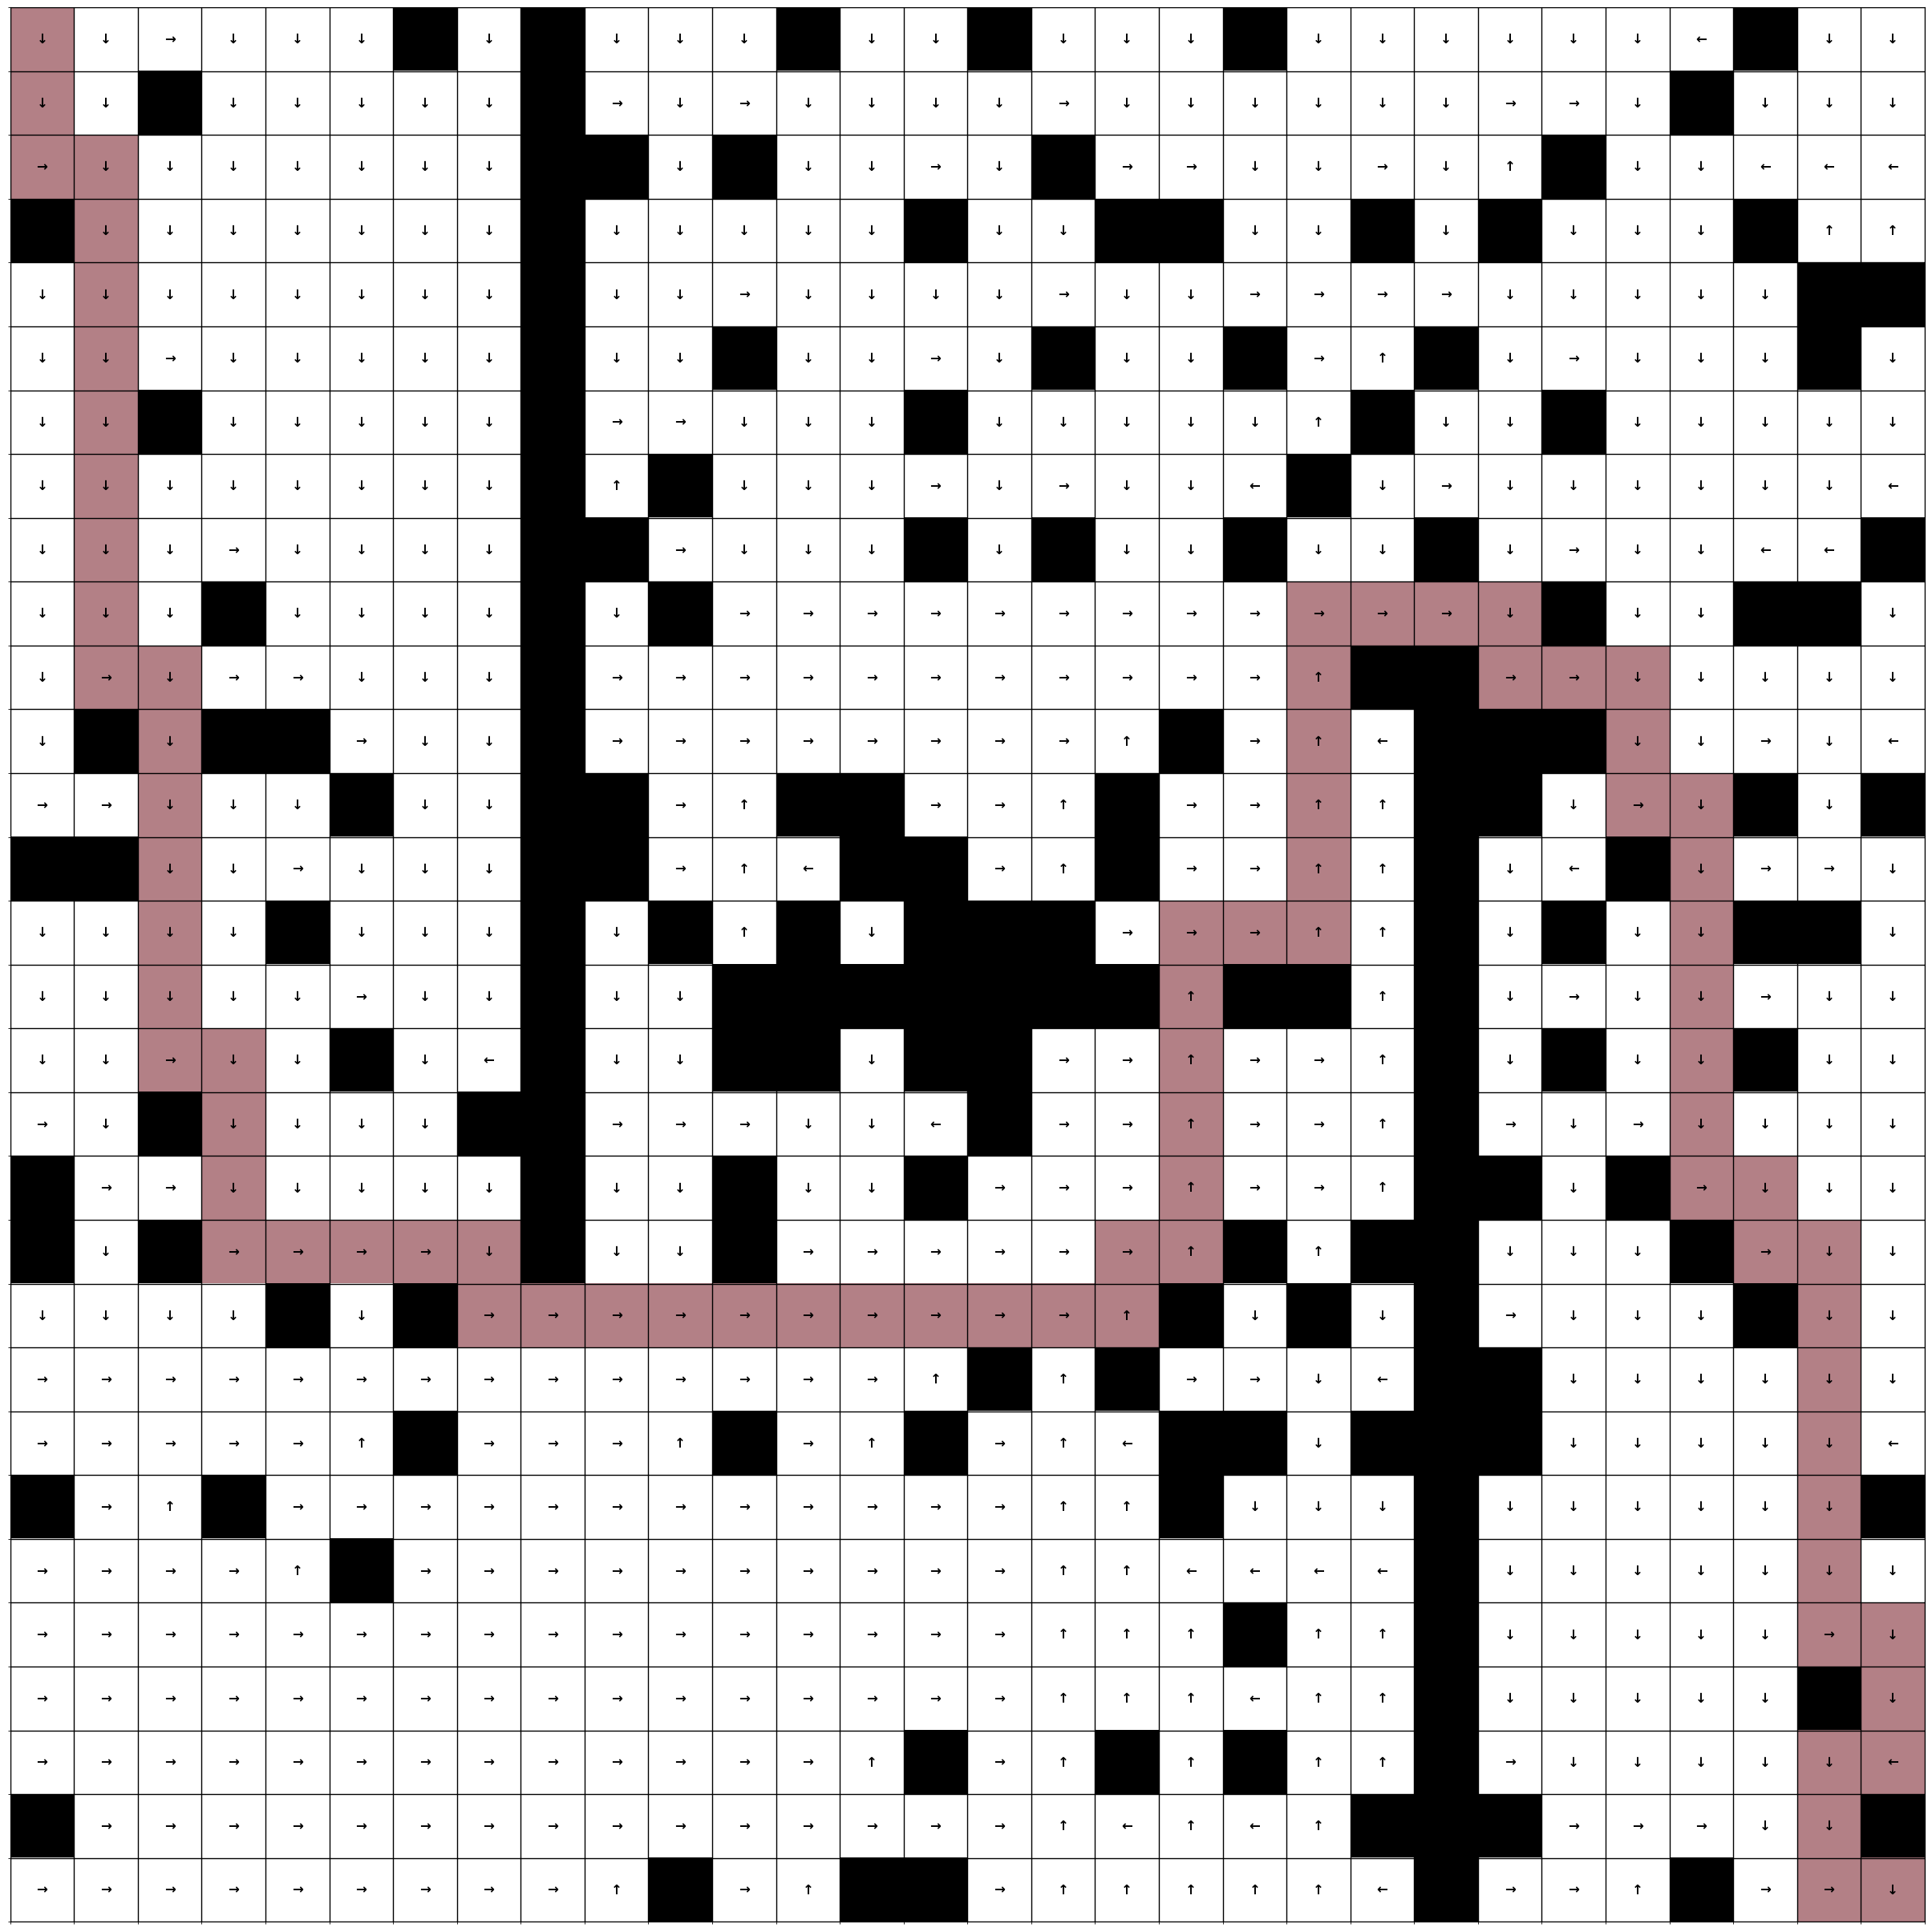

In [53]:
for _ in range(50):
    pi=greedy_policy(v)
    v=B_pi(v,pi)

plot(pi,path=True)

*Question 6*: Recommencer l'itération valeur, et s'arrêter lorsque la politique gloutonne reste inchangée pendant un certain nombre d'itérations (par exemple 100). A quelle itération cette politique a-t-elle été atteinte ? Combien de fois la fonction `transition` a-t-elle été appelée jusqu'à cette itération ?

In [52]:
v = np.random.random(maze.shape)

iter_count=0
unchanged_iterations=0

while unchanged_iterations<100:
    v_old=v.copy()
    if np.array_equal(v,v_old):
        unchanged_iterations+=1
    v=B_star(v) # nxm call de transition
    iter_count+=1

pi=greedy_policy(v) # nxmx4 call de transition

print(iter_count)
print(f'Nombre de call à transition: {iter_count*(maze.shape[0]*maze.shape[1])+(maze.shape[0]*maze.shape[1])}')

100
Nombre de call à transition: 90900


L'itération de valeur n'améliore pas forcément la politique à chaque itération car seul la fonction de valeur est améliorée, c'est pour ceci qu'on implémente un compteur.
En effet l'amélioration viens de v qui n'est pas forcément à jour et avec un seul pas en avant de prédiction.

*Question 7*: Implémenter une itération de politique, où pour chaque politique $\pi$ considérée, $v_{\pi}$ est approximée par 5 itérations de $B_{\pi}$. Combien de fois la fonction `transition` a-t-elle été appelée jusqu'à ce que la politique obtenue semble avoir convergé ?

In [56]:
v = np.random.random(maze.shape)
pi=greedy_policy(v)

iter_count=0

while True:
    
    for _ in range(5):
        v=B_pi(v,pi) # nxm*4 call de transition
    pi_new=greedy_policy(v) # nxmx4 call de transition

    if np.array_equal(pi,pi_new):
        break
    pi=pi_new
    iter_count+=1

print(iter_count)
print(f'Nombre de call à transition: {iter_count*(maze.shape[0]*maze.shape[1])*5}')

53
Nombre de call à transition: 238500


L'itération de politique choisi une politique meilleure (monotonie) et se stabilise à la politique optimale, on n'a pas besoin de faire tourner un compteur.
On améliore $v_\pi$ en tournant plusieurs fois v dans l'opérateur de Bellman, on compute à chaque fois un peu plus loin dans le futur ou autour de l'état.
On a donc plus d'information sur l'environnement de l'état ce qui donne des meilleurs politiques avec moins de bruit.

# Itérations asynchrones pour le labyrinthe

Cet exercice reprend le problème du labyrinthe. On copie-collera tout le code nécessaire, ou alternativement, on continuera sur le notebook précédent. On travaillera avec un labyrinthe tiré une fois pour toutes.

**Question 1**: Reprendre l'itération état-valeur synchrone pour le contrôle et déterminer une politique optimale (avec un grand nombre d'itérations). Déterminer également le nombre de mises à jour au bout duquel cette politique optimale est obtenue pour la première fois (une itération de l'opérateur $B_*$ correspond à $\mathcal{S}$ mises à jour).

**Question 2**: Écrire une fonction `update_state` qui effectue une mise à jour d'itération état-valeur pour le contrôle seulement pour l'état donné en argument. La mise à jour sera faite sur une variable globale `v` qui sera définie plus tard.

In [ ]:
def update_state(s):
    global v

    # compléter

    v[s] = #compléter

    return None

**Question 3**: Effectuer une itération état-valeur asynchrone qui met à jour un état par itération, et qui parcourt les états de façon cyclique. Combien de mises à jour sont-elles nécessaires pour obtenir une politique optimale ? Essayer différents ordres de parcours des états.

In [ ]:
v = np.random.random(maze.shape)

# compléter

On souhaite à présent utiliser la structure du problème pour parcourir les états de façon plus efficace et diminuer le nombre de mises à jour permettant d'obtenir une politique optimale.

Pour un labyrinthe donné, il existe certains états $s$ pour lesquels on connaît immédiatement la valeur optimale $v_*(s)$.

**Question 4**: Écrire une fonction qui prend en argument une function état-valeur, et qui en renvoie une modifiée, où les valeurs optimales connues a priori ont été renseignées.

In [ ]:
def set_known_values(v):
    # compléter
    return v

Un autre idée importante est que la valeur avec laquelle un état $s$ est mis à jour ne dépend que d'un petit nombre d'autres états, appelés "sucesseurs", c'est-à-dire ceux vers lesquels il existe une transition avec probabilité non-nulle. Autrement dit, les $s'$ tels qu'il existe une action $a$ telle que $p(r,s'|s,a)>0$. On dit alors également que $s$ est un prédecesseur de $s'$.

De plus, la valeur d'un état, après une première mise à jour, n'a besoin d'être à nouveau mise à jour que si la valeur d'un sucesseur a été modifiée.

**Question 5**: Écrire une fonction `predecessors` qui renvoie sous la forme d'une liste l'ensemble des prédecesseurs d'un état $s$ donné en argument. Ne pas oublier qu'un état peut être un prédecesseur pour lui-même.

In [ ]:
def predecessors(s):
    # compléter

On souhaite effectuer des mises à jour sucessives, divisées en phases (ou "époques"), mettant en oeuvre les idées suivantes:
- chaque état sera mis à jour au plus une fois pendant une époque;
- à chaque fois que la valeur d'un état est mis à jour (et que la mise à jour a entraîné une modification de la valeur), on considère chacun de ses prédecesseurs: s'il n'a pas encore été mis à jour lors de cette époque, il est ajouté à une liste d'états à mettre à jour lors de l'époque courante; s'il a déjà été mis à jour lors de cette époque, il est ajouté à une liste d'états à mettre à jour lors de l'époque suivante;
- les listes d'état à mettre à jour seront utilisées en FIFO (first in, first out): on ajoute un nouvel élement en fin de liste avec `.append()`, et on retire un élément en début de liste avec `.pop()`;
- on commence la première époque par les prédecesseurs de l'état "d'arrivée".

**Question 6**: Modifier la fonction `update_state` afin de mettre en oeuvre ces idées. La fonction interagira avec les variables globales `updated_states`, `states_to_update`, `states_to_update_next_epoch`, `epoch`.

In [ ]:
def update_state(s):
    global v, updated_states, states_to_update, states_to_update_next_epoch, epoch

    # compléter

**Question 7**: Mettre en oeuvre la démarche décrite ci-dessus et observer le nombre de mises à jour nécessaires pour obtenir une politique optimale.

In [ ]:
nb_epochs = 100
v = np.random.random(maze.shape)
v = set_known_values(v)

# compléter

for epoch in range(nb_epochs):
    #compléter

**Question 8**: Mettre en oeuvre une variante où les mises à jour ne sont pas divisées en époques, et où les prédécesseurs à mettre à jour sont tous ajoutés à la même liste, et comparer le nombre de mises à jour nécessaires pour obtenir une politique optimale. Expliquer la différence.